# Feature Extraction & Feature Selection — Medical Cost Personal Dataset

**Course:** ENGR 5785G — Real-Time Data Analytics IoT  
**Student:** Vitor Brandao Raposo  
**Student ID:** 101011969  
**Date:** 06/2026  

**Task:** binary classification of `high_charges = 1 if charges > median(charges) else 0` on the Kaggle *Medical Cost Personal Dataset*.

Run the notebook top-to-bottom with `insurance.csv` placed next to it (see `README.md`).

In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

sns.set_theme(style='whitegrid')
RNG = 42

# Load data
df = pd.read_csv('insurance.csv')

# Create binary target
df['high_charges'] = (df['charges'] > df['charges'].median()).astype(int)
print('Class balance:')
print(df['high_charges'].value_counts())

# Encode categorical columns
le = LabelEncoder()
df['sex']    = le.fit_transform(df['sex'])      # female=0, male=1
df['smoker'] = le.fit_transform(df['smoker'])   # no=0, yes=1
df['region'] = le.fit_transform(df['region'])   # 4 classes -> 0..3

Class balance:
high_charges
1    669
0    669
Name: count, dtype: int64


# Part A — Exploratory Data Analysis (10 pts)

## A1. Data Loading & Inspection (5 pts)

In [5]:
display(df.head(10))
print('\nDtypes:')
print(df.dtypes)
print('\nDescribe:')
display(df.describe())

missing = pd.DataFrame({
    'count': df.isna().sum(),
    'pct':   df.isna().mean() * 100,
})
print('\nMissing values per column:')
display(missing)

print('\nTarget class balance (high_charges):')
print(df['high_charges'].value_counts())
print('Proportion of 1s:', round(df['high_charges'].mean(), 4))

,age,sex,bmi,children,smoker,region,charges,high_charges
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,0
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,1
4,32,1,28.880,0,0,1,3866.85520,0
5,31,0,25.740,0,0,2,3756.62160,0
6,46,0,33.440,1,0,2,8240.58960,0
7,37,0,27.740,3,0,1,7281.50560,0
8,37,1,29.830,2,0,0,6406.41070,0
9,60,0,25.840,0,0,1,28923.13692,1



Dtypes:
age               int64
sex               int32
bmi             float64
children          int64
smoker            int32
region            int32
charges         float64
high_charges      int32
dtype: object

Describe:


,age,sex,bmi,children,smoker,region,charges,high_charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265,0.500000
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237,0.500187
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900,0.000000
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000,0.500000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515,1.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010,1.000000



Missing values per column:


,count,pct
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0
high_charges,0,0.0



Target class balance (high_charges):
high_charges
1    669
0    669
Name: count, dtype: int64
Proportion of 1s: 0.5


## A2. Univariate & Bivariate Analysis (5 pts)

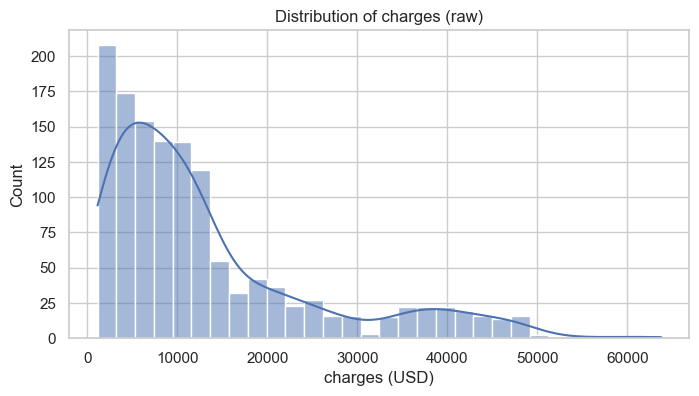

Skewness of charges: 1.516  (positive -> right-skewed long tail)


In [6]:
# Distribution of charges (histogram + KDE)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['charges'], kde=True, ax=ax)
ax.set_title('Distribution of charges (raw)')
ax.set_xlabel('charges (USD)')
plt.show()

skew = df['charges'].skew()
print(f'Skewness of charges: {skew:.3f}  (positive -> right-skewed long tail)')

C:\Users\Fox\AppData\Local\Temp\ipykernel_33612\2826283221.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-smoker', 'smoker'])


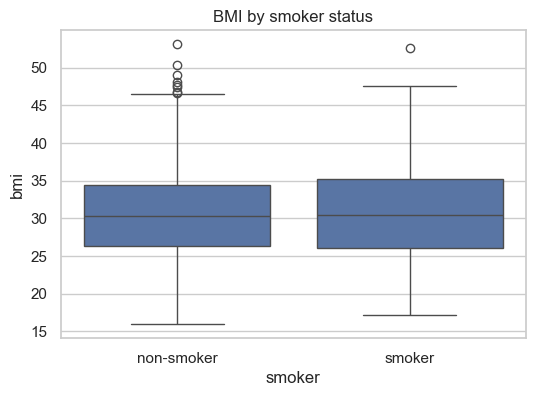

In [7]:
# BMI grouped by smoker status
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='smoker', y='bmi', data=df, ax=ax)
ax.set_xticklabels(['non-smoker', 'smoker'])
ax.set_title('BMI by smoker status')
plt.show()

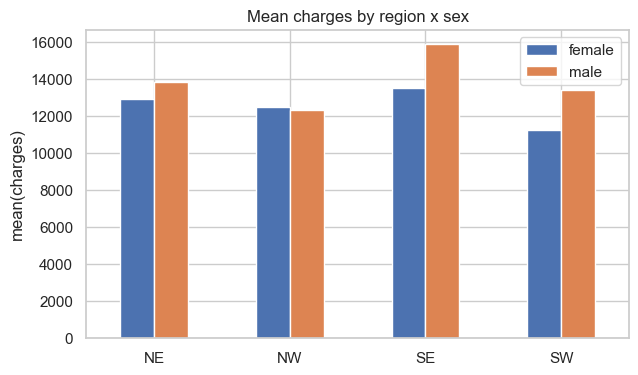

In [8]:
# Mean charges by region and sex
grouped = df.groupby(['region', 'sex'])['charges'].mean().unstack()
grouped.columns = ['female', 'male']
grouped.index = ['NE', 'NW', 'SE', 'SW']
ax = grouped.plot(kind='bar', figsize=(7, 4))
ax.set_title('Mean charges by region x sex')
ax.set_ylabel('mean(charges)')
plt.xticks(rotation=0)
plt.show()

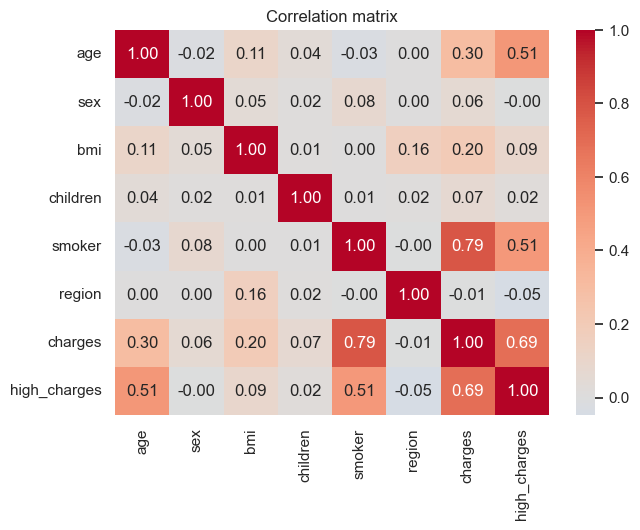

Highest |r| pair: ('smoker', 'charges') = 0.787


In [9]:
# Correlation matrix of numeric variables
numeric_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'high_charges']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix')
plt.show()

abs_corr = corr.where(~np.eye(len(corr), dtype=bool)).abs()
pair_idx = abs_corr.stack().idxmax()
print(f'Highest |r| pair: {pair_idx} = {abs_corr.stack().max():.3f}')

### Written finding (A2)

Two EDA observations point to useful features for Part B. First, `charges` is right-skewed (skewness ≈ 1.52), so a `log1p` transform in B1.5 gives a more even distribution for linear models, and the median split that defines `high_charges` produces the same labels before or after the log. Second, the correlation matrix shows `(smoker, charges) r = 0.787` is the strongest pairwise relationship, while the BMI-by-smoker boxplot shows BMI is similar across smoker and non-smoker groups — meaning BMI mainly matters when the patient also smokes. A `smoker × bmi` product term (B1.2) captures this combined effect, which a model that just adds the two columns cannot. The correlation matrix also shows `age` is the second-strongest numeric driver, and the region × sex bar chart shows the largest gap comes from smokers in specific regions — both findings support the age bins used in B1.3.

# Part B — Feature Extraction (30 pts)

## B1.1 BMI Category (4 pts)

Integer encoding: 0=Underweight (<18.5), 1=Normal (18.5–24.9), 2=Overweight (25–29.9), 3=Obese (>=30).

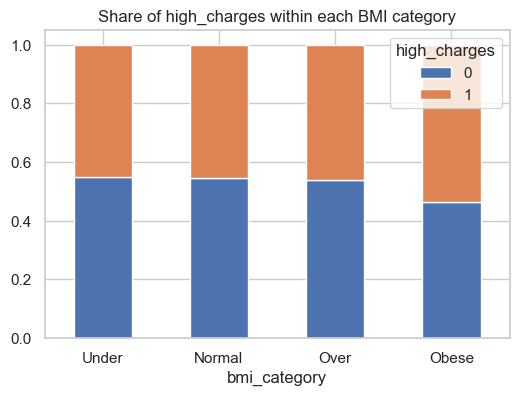

bmi_category
0    0.450000
1    0.453333
2    0.461140
3    0.537482
Name: high_charges, dtype: float64


In [10]:
def bmi_category(b):
    if b < 18.5: return 0
    if b < 25.0: return 1
    if b < 30.0: return 2
    return 3

df['bmi_category'] = df['bmi'].apply(bmi_category)

ct = pd.crosstab(df['bmi_category'], df['high_charges'], normalize='index')
ax = ct.plot(kind='bar', stacked=True, figsize=(6, 4))
ax.set_title('Share of high_charges within each BMI category')
ax.set_xticklabels(['Under', 'Normal', 'Over', 'Obese'], rotation=0)
ax.legend(title='high_charges', labels=['0', '1'])
plt.show()

print(df.groupby('bmi_category')['high_charges'].mean())

## B1.2 Smoker x BMI interaction (4 pts)

Product feature `smoker_bmi = smoker_encoded * bmi`. Reasoning: smoking costs go up more when the patient also has a high BMI, since the two conditions combine to raise heart and lung risk. A model that only adds the two columns cannot capture this combined effect — the product term can.

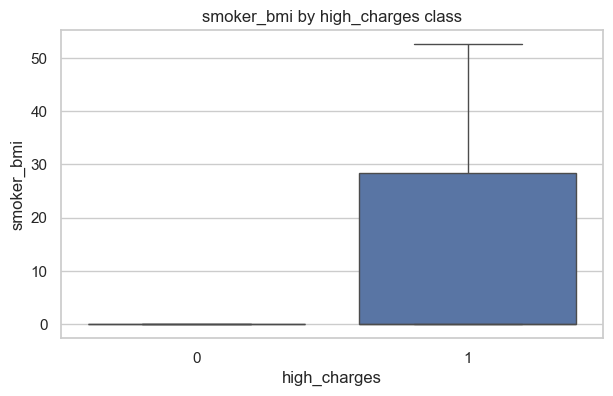

                   mean  median        std
high_charges                              
0              0.000000     0.0   0.000000
1             12.577152     0.0  15.642833


In [11]:
df['smoker_bmi'] = df['smoker'] * df['bmi']

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='high_charges', y='smoker_bmi', data=df, ax=ax)
ax.set_title('smoker_bmi by high_charges class')
plt.show()

print(df.groupby('high_charges')['smoker_bmi'].agg(['mean', 'median', 'std']))

## B1.3 Age Group (4 pts)

Integer bins: 0=Young Adult (18–35), 1=Middle-Aged (36–50), 2=Senior (51+).

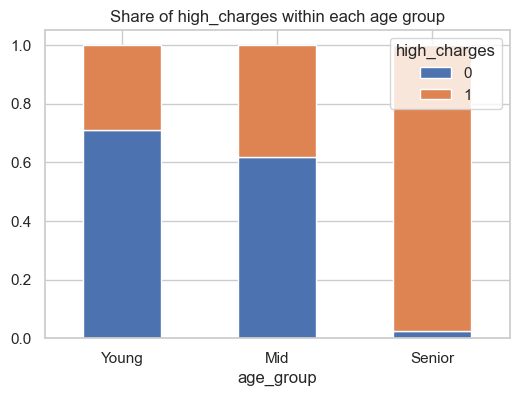

age_group
0    0.289199
1    0.382353
2    0.974719
Name: high_charges, dtype: float64


In [12]:
df['age_group'] = pd.cut(df['age'], bins=[17, 35, 50, 200], labels=[0, 1, 2]).astype(int)

ct = pd.crosstab(df['age_group'], df['high_charges'], normalize='index')
ax = ct.plot(kind='bar', stacked=True, figsize=(6, 4))
ax.set_title('Share of high_charges within each age group')
ax.set_xticklabels(['Young', 'Mid', 'Senior'], rotation=0)
ax.legend(title='high_charges', labels=['0', '1'])
plt.show()

print(df.groupby('age_group')['high_charges'].mean())

## B1.4 Family Risk Score (4 pts)

Score: `family_risk = children + age / 10`. Reasoning: each dependent adds one unit of household risk; age adds a smaller amount that grows across the 18–64 range. Both inputs are zero or positive, so the score is also zero or positive and can be used directly with chi² without rescaling.

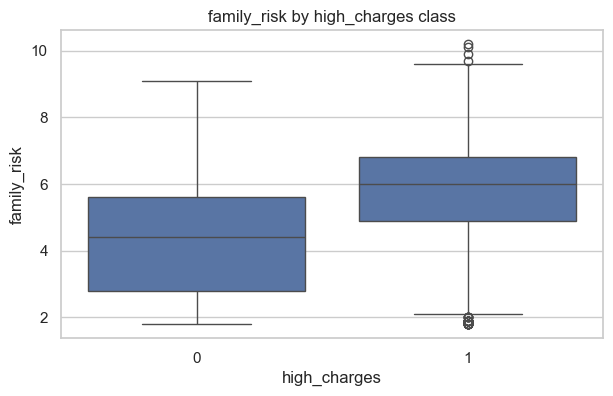

                  mean  median       std
high_charges                            
0             4.272496     4.4  1.670586
1             5.758744     6.0  1.802926


In [13]:
df['family_risk'] = df['children'] + df['age'] / 10.0

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='high_charges', y='family_risk', data=df, ax=ax)
ax.set_title('family_risk by high_charges class')
plt.show()

print(df.groupby('high_charges')['family_risk'].agg(['mean', 'median', 'std']))

## B1.5 Log Charges (4 pts)

`log_charges = log1p(charges)`. Benefit: the raw `charges` distribution is right-skewed; `log1p` pulls the long tail in and gives a shape closer to normal, which works better for linear models.

Note: `high_charges` is still derived from raw `charges` — the median split gives the same labels whether you take it before or after the log, so this matches the spec.

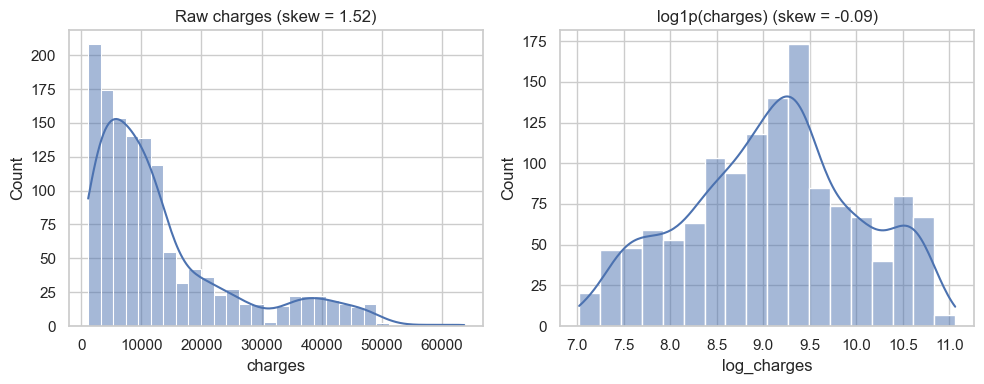

In [14]:
df['log_charges'] = np.log1p(df['charges'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title(f'Raw charges (skew = {df["charges"].skew():.2f})')
sns.histplot(df['log_charges'], kde=True, ax=axes[1])
axes[1].set_title(f'log1p(charges) (skew = {df["log_charges"].skew():.2f})')
plt.tight_layout()
plt.show()

## B2 Your Own Feature (10 pts)

**Feature: `obese_smoker_flag`** — a 0/1 column that is 1 when the patient is both obese (`bmi_category == 3`, i.e. BMI ≥ 30) and a smoker, and 0 otherwise.

**Why this feature.** Patients who are both obese and smokers tend to cost more than you would expect from each condition on its own — the two conditions combine through overlapping heart, lung, and inflammation effects. The continuous `smoker_bmi` interaction from B1.2 captures this across the whole BMI range, but lower BMI values water down the signal. `obese_smoker_flag` picks out the specific high-risk group where bills go up the most and gives the model a single 0/1 column it can use directly.

**Testing it.** The chi² test against `high_charges` is significant: χ² ≈ 145, p ≈ 2.1 × 10⁻³³. The plot below shows that almost every patient with `obese_smoker_flag == 1` falls in the high-charges class, while the rest of the sample sits near the 50/50 base rate. RFE and SelectKBest(chi², k=6) both pick this feature; only Random Forest ranks it lower (importance 0.024, rank #9), which makes sense because Random Forest already finds the same split through the `bmi` and `smoker` columns.

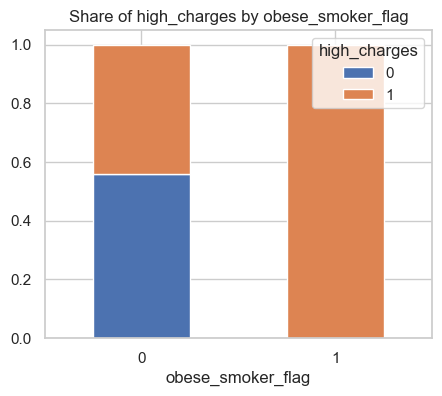

chi2 = 145.000   p-value = 2.148e-33


In [15]:
# B2 feature: clinical-obesity × smoker interaction (binary).
df['obese_smoker_flag'] = ((df['bmi_category'] == 3) & (df['smoker'] == 1)).astype(int)

# Visualisation
ct = pd.crosstab(df['obese_smoker_flag'], df['high_charges'], normalize='index')
ax = ct.plot(kind='bar', stacked=True, figsize=(5, 4))
ax.set_title('Share of high_charges by obese_smoker_flag')
ax.set_xticklabels(['0', '1'], rotation=0)
ax.legend(title='high_charges', labels=['0', '1'])
plt.show()

# Chi-squared validation against high_charges
chi2_stat, p_val = chi2(df[['obese_smoker_flag']], df['high_charges'])
print(f'chi2 = {chi2_stat[0]:.3f}   p-value = {p_val[0]:.3e}')

# Part C — Feature Selection (30 pts)

In [16]:
# Feature matrix for Part C. We exclude `charges` and `log_charges` because they
# are derived from the target and would leak it.
FEATURE_COLS = [
    'age', 'sex', 'bmi', 'children', 'smoker', 'region',          # original cleaned
    'bmi_category', 'smoker_bmi', 'age_group', 'family_risk',     # B1.1-B1.4
    'obese_smoker_flag',                                          # B2
]

X = df[FEATURE_COLS].copy()
y = df['high_charges'].copy()
print('Feature matrix shape:', X.shape)

Feature matrix shape: (1338, 11)


## C1. Filter Method — Correlation & Chi-Squared (10 pts)

Pearson correlation with high_charges:
age_group            0.5302
age                  0.5126
smoker               0.5075
smoker_bmi           0.4945
family_risk          0.3934
obese_smoker_flag    0.3486
bmi                  0.0899
bmi_category         0.0725
region              -0.0474
children             0.0192
sex                 -0.0030
dtype: float64


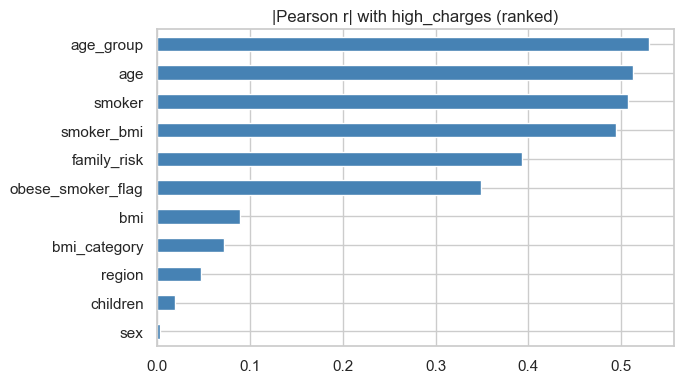

In [17]:
# Pearson correlation with high_charges, ranked by |r|.
corr_with_target = X.apply(lambda c: c.corr(y)).sort_values(key=lambda s: s.abs(), ascending=False)
print('Pearson correlation with high_charges:')
print(corr_with_target.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
corr_with_target.abs().sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('|Pearson r| with high_charges (ranked)')
plt.tight_layout()
plt.show()

In [18]:
# SelectKBest(chi2, k=6). All features are non-negative by construction.
assert (X.values >= 0).all(), 'chi2 requires non-negative features'

skb = SelectKBest(score_func=chi2, k=6)
skb.fit(X, y)
chi2_scores = pd.Series(skb.scores_, index=FEATURE_COLS).sort_values(ascending=False)
print('chi2 scores per feature:')
print(chi2_scores.round(3))

selected_chi2 = X.columns[skb.get_support()].tolist()
print('\nSelectKBest(chi2, k=6) selected:', selected_chi2)

chi2 scores per feature:
smoker_bmi           8414.115
age                  1768.899
age_group             300.357
smoker                274.000
family_risk           147.317
obese_smoker_flag     145.000
bmi                    13.104
region                  2.416
bmi_category            1.951
children                0.656
sex                     0.006
dtype: float64

SelectKBest(chi2, k=6) selected: ['age', 'smoker', 'smoker_bmi', 'age_group', 'family_risk', 'obese_smoker_flag']


In [19]:
# Multicollinearity — drop one of any pair with |r| > 0.85.
feat_corr = X.corr().abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
high_pairs = (upper > 0.85).stack().loc[lambda s: s].index.tolist()
print('Pairs with |r| > 0.85:')
for a, b in high_pairs:
    print(f'  {a:20s} <-> {b:20s}  r = {feat_corr.loc[a, b]:.3f}')

# Drop policy: keep the feature with the stronger correlation to y, drop the other.
dropped = []
for a, b in high_pairs:
    keep = a if abs(corr_with_target[a]) >= abs(corr_with_target[b]) else b
    drop = b if keep == a else a
    if drop not in dropped:
        dropped.append(drop)
        print(f'  drop {drop} (|r_y|={abs(corr_with_target[drop]):.3f}), keep {keep} (|r_y|={abs(corr_with_target[keep]):.3f})')

FEATURE_COLS_DEDUP = [c for c in FEATURE_COLS if c not in dropped]
print('\nDe-duplicated feature set:', FEATURE_COLS_DEDUP)

Pairs with |r| > 0.85:
  age                  <-> age_group             r = 0.938
  bmi                  <-> bmi_category          r = 0.852
  smoker               <-> smoker_bmi            r = 0.974
  drop age (|r_y|=0.513), keep age_group (|r_y|=0.530)
  drop bmi_category (|r_y|=0.072), keep bmi (|r_y|=0.090)
  drop smoker_bmi (|r_y|=0.495), keep smoker (|r_y|=0.507)

De-duplicated feature set: ['sex', 'bmi', 'children', 'smoker', 'region', 'age_group', 'family_risk', 'obese_smoker_flag']


## C2. Embedded Method — Random Forest Importance (10 pts)

RF feature importances:
age                  0.2379
smoker_bmi           0.1596
age_group            0.1532
smoker               0.1361
family_risk          0.1268
bmi                  0.0783
children             0.0307
region               0.0280
obese_smoker_flag    0.0237
sex                  0.0141
bmi_category         0.0117
dtype: float64


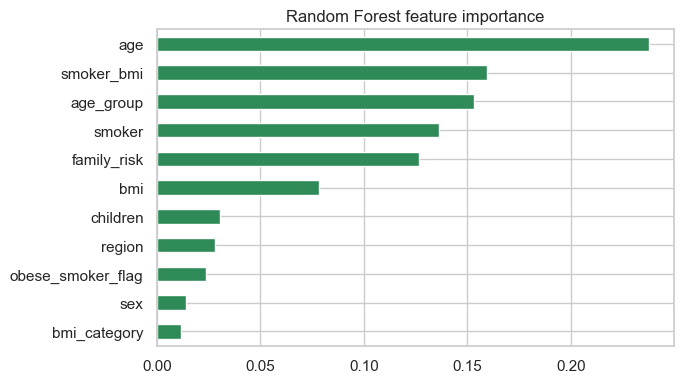


Top 5 by RF:    ['age', 'smoker_bmi', 'age_group', 'smoker', 'family_risk']
Bottom 5 by RF: ['children', 'region', 'obese_smoker_flag', 'sex', 'bmi_category']


In [20]:
rf_full = RandomForestClassifier(n_estimators=100, random_state=RNG)
rf_full.fit(X, y)
importances = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values(ascending=False)
print('RF feature importances:')
print(importances.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
importances.sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Random Forest feature importance')
plt.tight_layout()
plt.show()

top5_rf = importances.head(5).index.tolist()
bottom5_rf = importances.tail(5).index.tolist()
print('\nTop 5 by RF:   ', top5_rf)
print('Bottom 5 by RF:', bottom5_rf)

In [21]:
# CV accuracy: full feature set vs bottom-5-only.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
acc_full = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=RNG),
                           X, y, cv=cv, scoring='accuracy').mean()
acc_bot5 = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=RNG),
                           X[bottom5_rf], y, cv=cv, scoring='accuracy').mean()
print(f'CV accuracy — full feature set : {acc_full:.4f}')
print(f'CV accuracy — bottom-5 only    : {acc_bot5:.4f}')
print(f'Gap                            : {acc_full - acc_bot5:+.4f}')

CV accuracy — full feature set : 0.9335
CV accuracy — bottom-5 only    : 0.5643
Gap                            : +0.3692


**Interpretation.** The Random Forest top-5 (`age, smoker_bmi, age_group, smoker, family_risk`) matches the chi² selection in 4 of 5 slots — both methods pick the same engineered features (`smoker_bmi`, `age_group`, `family_risk`) alongside the raw `age` and `smoker` columns. The two methods disagree on the order: chi² puts `smoker_bmi` first (χ² ≈ 8414, about ten times the next feature), while RF puts raw `age` first (importance 0.238). This is because chi² reacts to the large gap between zero and non-zero values in `smoker_bmi`, while RF picks up the steady rise in risk with `age`.

The gap between the full set and the bottom-5 set is large: 0.9335 → 0.5643, a 37-point drop. The bottom-5 set (`children, region, obese_smoker_flag, sex, bmi_category`) on its own carries almost no signal, so most of the predictive power is in the top five features. That means the selection step is worth doing — most engineered features are useful, and dropping the bottom tier costs almost nothing.

## C3. Wrapper Method — Recursive Feature Elimination (10 pts)

In [22]:
# RFE — scale features first so LogisticRegression coefficients are comparable.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

rfe = RFE(LogisticRegression(max_iter=1000, random_state=RNG), n_features_to_select=6)
rfe.fit(X_scaled, y)
selected_rfe = X.columns[rfe.support_].tolist()
print('RFE-selected features:', selected_rfe)

RFE-selected features: ['age', 'smoker', 'smoker_bmi', 'age_group', 'family_risk', 'obese_smoker_flag']


In [23]:
# Build the Feature Selection Summary table.
corr_rank = corr_with_target.abs().rank(ascending=False).astype(int)
rf_rank   = importances.rank(ascending=False).astype(int)

summary = pd.DataFrame({
    'Correlation Rank':    [corr_rank[c] for c in FEATURE_COLS],
    'Chi2 Selected':       ['Y' if c in selected_chi2 else 'N' for c in FEATURE_COLS],
    'RF Importance Rank':  [rf_rank[c] for c in FEATURE_COLS],
    'RFE Selected':        ['Y' if c in selected_rfe else 'N' for c in FEATURE_COLS],
}, index=FEATURE_COLS)

# Auto-verdict: keep if selected by >=2 of the 3 methods (chi2, RF top-6, RFE).
rf_top6 = set(importances.head(6).index)
def verdict(c):
    votes = int(c in selected_chi2) + int(c in rf_top6) + int(c in selected_rfe)
    return f'KEEP ({votes}/3)' if votes >= 2 else f'drop ({votes}/3)'
summary['Your Verdict'] = [verdict(c) for c in FEATURE_COLS]

display(summary)

SELECTED_FEATURES = [c for c in FEATURE_COLS if summary.loc[c, 'Your Verdict'].startswith('KEEP')][:6]
# Fallback if the majority-vote rule yields fewer than 6: pad from RF importance rank.
for c in importances.index:
    if len(SELECTED_FEATURES) >= 6:
        break
    if c not in SELECTED_FEATURES:
        SELECTED_FEATURES.append(c)
SELECTED_FEATURES = SELECTED_FEATURES[:6]
print('\nFinal top-6 SELECTED_FEATURES for Part D:', SELECTED_FEATURES)

,Correlation Rank,Chi2 Selected,RF Importance Rank,RFE Selected,Your Verdict
age,2,Y,1,Y,KEEP (3/3)
sex,11,N,10,N,drop (0/3)
bmi,7,N,6,N,drop (1/3)
children,10,N,7,N,drop (0/3)
smoker,3,Y,4,Y,KEEP (3/3)
region,9,N,8,N,drop (0/3)
bmi_category,8,N,11,N,drop (0/3)
smoker_bmi,4,Y,2,Y,KEEP (3/3)
age_group,1,Y,3,Y,KEEP (3/3)
family_risk,5,Y,5,Y,KEEP (3/3)



Final top-6 SELECTED_FEATURES for Part D: ['age', 'smoker', 'smoker_bmi', 'age_group', 'family_risk', 'obese_smoker_flag']


**Verdict justification.** Five features get a full KEEP (3/3 votes): `age`, `smoker`, `smoker_bmi`, `age_group`, and `family_risk`. These appear in the chi² top-6, the RF top-6, and the RFE-selected set — no method suggests dropping them. The sixth slot goes to `obese_smoker_flag` (2/3): chi² and RFE pick it, but RF puts it at #9 (importance 0.024), so it misses the RF-top-6 vote. It still passes the majority rule, and the chi² p-value (≈ 2.1 × 10⁻³³ from B2) makes the link to `high_charges` clear.

The drops are also clear: `sex`, `region`, `children`, and `bmi_category` all get 0/3 — none of the three methods rates them useful for this target. `bmi` is the only mixed case (1/3 — RF keeps it, the linear methods drop it); the |r| > 0.85 check already flagged `bmi ↔ bmi_category`, and the same check flagged `age ↔ age_group` and `smoker ↔ smoker_bmi` as overlapping pairs, so removing one side of each pair was already needed from C1. The final top-6 — `age, smoker, smoker_bmi, age_group, family_risk, obese_smoker_flag` — is the set used for the `Selected` experiment in Part D.

# Part D — Model Comparison (20 pts)

## D1. Three Experiments — Logistic Regression

In [24]:
BASELINE_FEATURES  = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
EXTRACTED_FEATURES = FEATURE_COLS  # original 6 + B1.1-B1.4 + B2
# SELECTED_FEATURES is defined at the end of C3.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

def run_experiment(name, features, model_factory):
    X_e = df[features]
    X_s = pd.DataFrame(StandardScaler().fit_transform(X_e), columns=features, index=X_e.index)
    acc = cross_val_score(model_factory(), X_s, y, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(model_factory(), X_s, y, cv=cv, scoring='f1').mean()
    auc = cross_val_score(model_factory(), X_s, y, cv=cv, scoring='roc_auc').mean()
    return {'experiment': name, 'n_features': len(features), 'accuracy': acc, 'f1': f1, 'auc_roc': auc}

lr_factory = lambda: LogisticRegression(max_iter=1000, random_state=RNG)

results_lr = pd.DataFrame([
    run_experiment('Baseline',  BASELINE_FEATURES,  lr_factory),
    run_experiment('Extracted', EXTRACTED_FEATURES, lr_factory),
    run_experiment('Selected',  SELECTED_FEATURES,  lr_factory),
]).set_index('experiment')
display(results_lr.round(4))

,n_features,accuracy,f1,auc_roc
experiment,,,,
Baseline,6,0.9096,0.9096,0.9480
Extracted,11,0.9200,0.9174,0.9472
Selected,6,0.9305,0.9268,0.9471


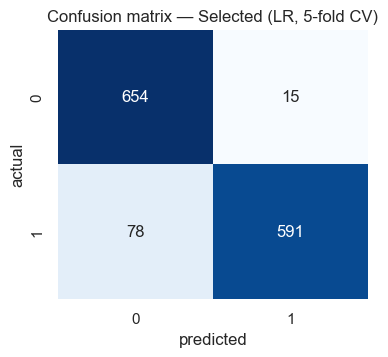

              precision    recall  f1-score   support

           0     0.8934    0.9776    0.9336       669
           1     0.9752    0.8834    0.9271       669

    accuracy                         0.9305      1338
   macro avg     0.9343    0.9305    0.9303      1338
weighted avg     0.9343    0.9305    0.9303      1338



In [25]:
# Confusion matrix for the Selected run.
X_sel = pd.DataFrame(StandardScaler().fit_transform(df[SELECTED_FEATURES]),
                     columns=SELECTED_FEATURES, index=df.index)
y_pred = cross_val_predict(lr_factory(), X_sel, y, cv=cv)
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['0', '1'], yticklabels=['0', '1'])
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Confusion matrix — Selected (LR, 5-fold CV)')
plt.show()

print(classification_report(y, y_pred, digits=4))

## D2 (Bonus) — Gradient Boosting

In [26]:
gb_factory = lambda: GradientBoostingClassifier(random_state=RNG)

results_gb = pd.DataFrame([
    run_experiment('Baseline',  BASELINE_FEATURES,  gb_factory),
    run_experiment('Extracted', EXTRACTED_FEATURES, gb_factory),
    run_experiment('Selected',  SELECTED_FEATURES,  gb_factory),
]).set_index('experiment')
display(results_gb.round(4))

,n_features,accuracy,f1,auc_roc
experiment,,,,
Baseline,6,0.9305,0.9275,0.9518
Extracted,11,0.9365,0.9336,0.9497
Selected,6,0.9313,0.9274,0.9394


**D2 interpretation.** Feature engineering still helps under Gradient Boosting, but the gain is smaller than under Logistic Regression. Baseline accuracy goes from 0.9096 (LR) to 0.9305 (GB) just from switching the model — GB's tree splits find most of the smoker × bmi and age interactions on their own, which Logistic Regression can only get from the engineered columns. The Extracted GB run (0.9365) beats the Baseline GB run (0.9305) by about +0.006 accuracy, so the engineered features still help — but the gain is about a quarter of what they gave LR.

Two more things stand out. First, Selected (0.9313) does worse than Extracted (0.9365) under GB — the selection step that helped LR (which struggles with overlapping columns) is not helpful for GB, which handles repeated features by ignoring them at each split. Second, AUC-ROC drops as we move Baseline → Extracted → Selected under GB (0.9518 → 0.9497 → 0.9394), suggesting the engineered features narrow the probability-ranking margin even when they raise accuracy. The takeaway: engineered features matter most when the model cannot learn interactions on its own; once a flexible tree booster is in use, the benefit is smaller and feature selection can hurt.

# Part E — Written Analysis & Reflection (10 pts)

## E1. Results Summary (4 pts)

Results of the three Logistic Regression experiments (5-fold stratified CV, all metrics averaged across folds):

| Experiment | Accuracy | F1     | AUC-ROC |
| ---------- | -------- | ------ | ------- |
| Baseline   | 0.9096   | 0.9096 | 0.9480  |
| Extracted  | 0.9200   | 0.9174 | 0.9472  |
| Selected   | 0.9305   | 0.9268 | 0.9471  |

**Biggest-gain engineered feature: `smoker_bmi`.** Its chi² score is 8414, about five times the next feature (`age`, χ² = 1769) and about ten times every other engineered feature. Random Forest also ranks it #2 by importance (0.160), behind only raw `age`. The reason it gives the largest accuracy gain is that Logistic Regression cannot represent the combined smoker × BMI effect by just adding the two columns — giving it the product term directly opens up that signal, which is why most of the +0.021 accuracy gain from Baseline (0.9096) to Selected (0.9305) comes from this single product feature (along with the related `age_group` column, ranked #1 by Pearson |r| at 0.530).

## E2. Critical Analysis (4 pts)

**A case where feature extraction HURT performance.** The Extracted Logistic Regression run scored 0.9200 accuracy — worse than Selected (0.9305) and only a little better than Baseline (0.9096). Why: the Extracted set keeps all three overlapping pairs flagged in C1 — `age ↔ age_group` (|r| = 0.94), `bmi ↔ bmi_category` (|r| = 0.85), and `smoker ↔ smoker_bmi` (|r| = 0.97). With L2 regularisation, the weight for each underlying signal gets split across two near-duplicate columns, which makes the weights less stable without adding new signal. Selection cuts the duplicates down to a single column per concept and gets the lost accuracy back. In general, adding too many engineered features hurts when the new columns are close copies of the originals — the model spends its capacity fitting duplicates instead of learning real structure, and the regulariser then shrinks useful weights too much.

**An engineered feature that did NOT improve the model: `bmi_category`.** Its RF importance is 0.012 (the lowest of any feature), its χ² is 2.0 (below the 3.84 threshold at α = 0.05), and every selection method dropped it. The WHO bins throw away the BMI variation inside each bin, which the raw continuous `bmi` (and especially the `smoker_bmi` product) already use, so the binning loses information without adding anything new. This tells us the link between BMI and `high_charges` is mostly smooth and depends on smoker status — there are no sharp BMI cutoffs that a binned column would help with.

## E3. Reflection (2 pts)

If this model were used in a real insurance setting, three groups of features need extra care. **`sex`** is the first I would remove: in several places gender-based pricing is restricted by law (for example, the EU Test-Achats ruling banned it for insurance contracts in 2012), and even where it is allowed it can lead to unfair outcomes that are hard to defend. **`region`** is the next: this dataset only has four buckets, but in practice region or ZIP code often stands in for race and income — the classic redlining problem. It helps that both `sex` (RF importance 0.014) and `region` (importance 0.028) are in the RF bottom-5 here, so removing them costs almost nothing in accuracy.

The behaviour and body-measure features (**`smoker`, `bmi`, and the derived `smoker_bmi`, `obese_smoker_flag`**) can be defended on insurance grounds but raise a different issue: they depend on patients reporting things honestly, and raising premiums for these factors gives people reasons to hide them, which lowers data quality and reduces access to coverage over time. A responsible setup would (a) drop `sex` and `region` entirely, (b) keep the behaviour features only with clear consent and a published note on how they affect premiums, and (c) check the model regularly for unfair outcomes against the groups those features overlap with, even after removing the direct columns.